# Muon, Björck and max-derivative quintics as sign iterations
Three odd quintic updates run on the same matrix. Plot 1: spectral-norm error against the exact sign, per iteration $k$. Plot 2: for each polynomial, the singular values of $X_k$ at a few values of $k$ against the input singular values and the target 1. Muon's quintic has $p(1) 
eq 1$, so it does not converge to the sign: its singular values end up in a band around 1. Edit the config and rerun.

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so ns_core and experiments import

import matplotlib.pyplot as plt
import torch

from ns_core import plots
from experiments.cpwl_operator import CPWLOperatorConfig
from experiments.polynomial_comparison import PolynomialComparisonConfig, run_polynomial_comparison, run_quintic_cpwl, run_cpwl_comparison
%matplotlib inline

In [2]:
cfg = PolynomialComparisonConfig(
    m=64, n=64, rank=None, cond=2, sigma_max=1.0, spectrum="linear",
    polynomials=None,   # None = Muon, Björck, max derivative; or {name: ascending coeffs of x, x^3, x^5}
    k_max=100,           # steps
    eps=None,           # freeze the iterate once its error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cuda", seed=0,
)
cfg2 = PolynomialComparisonConfig(
    m=64, n=64, rank=None, cond=1e8, sigma_max=1.0, spectrum="linear",
    polynomials=None,   # None = Muon, Björck, max derivative; or {name: ascending coeffs of x, x^3, x^5}
    k_max=100,           # steps
    eps=None,           # freeze the iterate once its error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cuda", seed=0,
)
res = run_polynomial_comparison(cfg)
res2 = run_polynomial_comparison(cfg2)

## Plot 1: error against iterations

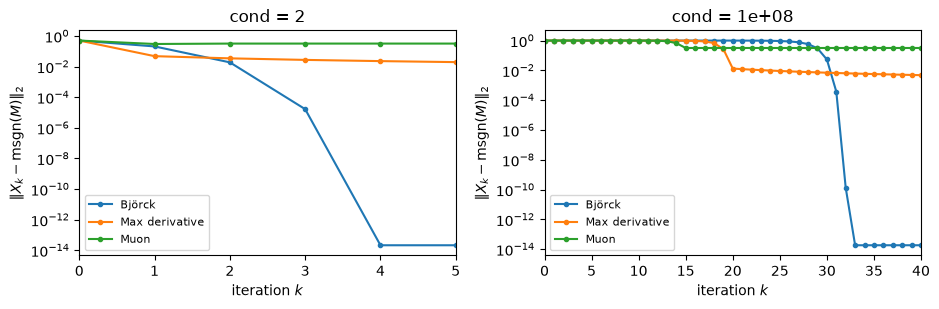

In [3]:
import os

names = {name: name for name in res["error"]}
fig, axs = plt.subplots(1, 2, figsize=(9.5, 3.2))
for ax, c, r, kshow in zip(axs, (cfg, cfg2), (res, res2), (5, 40)):
    plots.plot_error_curves(
        r["error"], ax=ax, labels=names,
        eps=c.eps,             # None = no markers or line
        show_first_hit=True,   # mark the first step with error <= eps
        show_eps_line=True,    # horizontal line at eps
        k_plot=kshow,          # last step shown (None = all)
    )
    ax.set_title(f"cond = {c.cond:g}")
fig.tight_layout()
os.makedirs("../figures", exist_ok=True)
fig.savefig(f"../figures/poly_comparison_m{cfg.m}_n{cfg.n}.pdf", bbox_inches="tight")

## Plot 2: spectrum convergence toward the sign

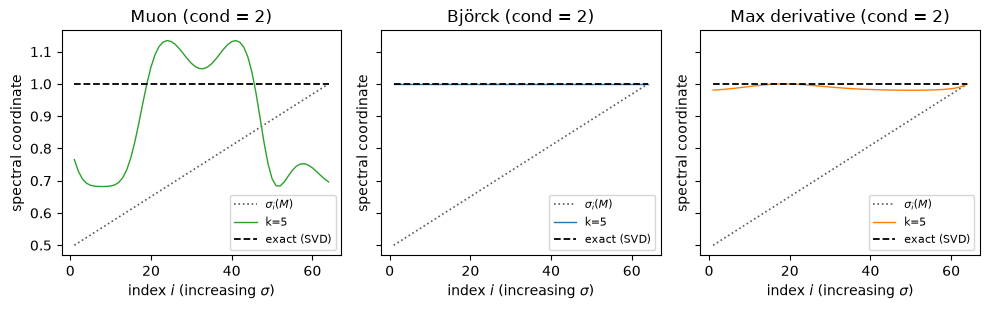

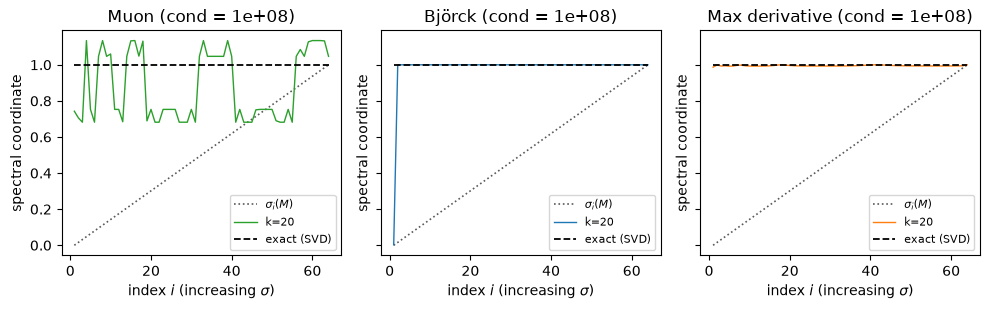

In [4]:
poly_colors = {"Muon": "tab:green", "Björck": "tab:blue", "Max derivative": "tab:orange"}
for c, r, k in [(cfg, res, 5), (cfg2, res2, 20)]:
    fig, axs = plt.subplots(1, len(r["coords"]), figsize=(10, 3.2), sharey=True)
    for ax, (name, coords) in zip(axs, r["coords"].items()):
        plots.plot_spectrum(
            r["sigma"], r["target"], coords, ax=ax,
            ks=[k],             # step counts to draw (None = all, up to cfg.k_max)
            xaxis="index",     # "sigma" (values) or "index" (rank order)
            labels=None,       # legend text per k; None = "k=..."
            color=poly_colors.get(name),   # None = one color per k
        )
        ax.set_title(f"{name} (cond = {c.cond:g})")
    fig.tight_layout()
    fig.savefig(f"../figures/poly_spectrum_cond{c.cond:g}_k{k}.pdf", bbox_inches="tight")

## CPWL operator on the max-derivative quintic
Every internal sign call runs exactly `n_iters` steps of the quintic; the clip operator is compared with the exact one (relative Frobenius error).

## CPWL operator through each polynomial (as in exp6)
The same three polynomials as the sign map inside the CPWL operator. Plot 1: relative Frobenius error of the operator against the exact one, per step count $k$. Plot 2: the operator's output spectrum at a few values of $k$ against the input singular values and the exact profile.

In [21]:
cpwl_cfg = CPWLOperatorConfig(
    m=64, n=64, rank=64, cond=1e1, sigma_max=1.0, spectrum="log",
    profile="clip", alpha=0, beta=0.5,
    eps=1e-8,   # error run stops once the operator error reaches this; None = 10 machine eps
    dtype=torch.float64, device="cuda", seed=0,
)
res_cpwl = run_cpwl_comparison(cpwl_cfg, polynomials=None, k_max=20)

### CPWL plot 1: error against iterations

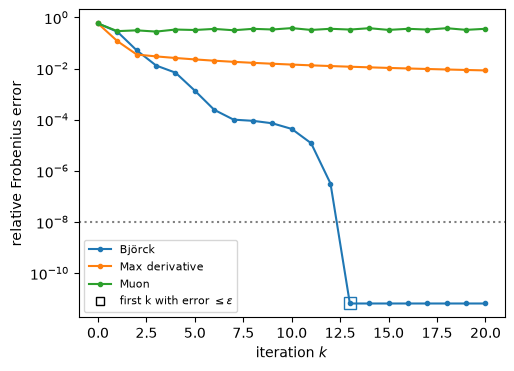

In [22]:
plots.plot_error_curves(
    res_cpwl["error"], labels={n: n for n in res_cpwl["error"]}, ylabel="relative Frobenius error",
    eps=cpwl_cfg.eps,      # None = no markers or line
    show_first_hit=True,   # mark the first step with error <= eps
    show_eps_line=True,    # horizontal line at eps
    k_plot=None,           # last step shown (None = all)
);

### CPWL plot 2: output spectrum

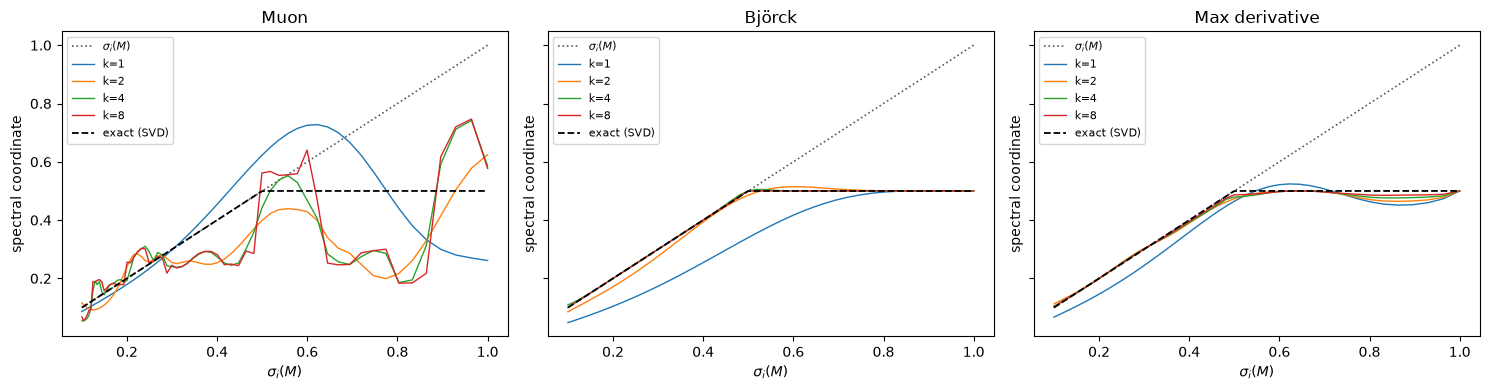

In [23]:
fig, axs = plt.subplots(1, len(res_cpwl["coords"]), figsize=(5 * len(res_cpwl["coords"]), 4), sharey=True)
for ax, (name, coords) in zip(axs, res_cpwl["coords"].items()):
    plots.plot_spectrum(
        res_cpwl["sigma"], res_cpwl["target"], coords, ax=ax,
        ks=[1, 2, 4, 8],   # step counts to draw (None = all, up to k_max)
        xaxis="sigma",     # "sigma" (values) or "index" (rank order)
        labels=None,       # legend text per k; None = "k=..."
    )
    ax.set_title(name)
fig.tight_layout()